# RoadSafe India — Statistical Analysis

## Objective

This notebook examines statistical relationships among reported road
accidents, reported fatalities and projected population across Indian
States/UTs in 2024.

The analysis focuses on:

1. Descriptive statistics.
2. Pearson correlation.
3. Spearman rank correlation.
4. Statistical significance of selected correlations.
5. Comparison of accident and fatality relationships.
6. Interpretation of relationships while considering population as an
   important contextual variable.

The analysis is observational and uses State/UT-level aggregated data.
Therefore, statistical associations identified in this notebook should not
be interpreted as causal relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
# Load the validated master State/UT analytical dataset

master_path = (
    "../data/processed/"
    "master_state_analysis_2024.csv"
)

df = pd.read_csv(master_path)

print("Master dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Master dataset loaded successfully.
Rows: 36
Columns: 26


,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,2020_killed,2021_killed,2022_killed,2023_killed,...,five_year_average_fatalities,fatality_years_available,accident_change_2020_to_2024,accident_percent_change_2020_to_2024,fatality_change_2020_to_2024,fatality_percent_change_2020_to_2024,accident_rank_2024,fatality_rank_2024,accident_rate_rank_2024,fatality_rate_rank_2024
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,7039.0,8186,8293,8137,...,8000.2,5,48.0,0.246040,1307.0,18.567978,9.0,8.0,11.0,8.0
1,Arunachal Pradesh,134.0,283.0,227.0,287.0,277.0,73.0,157,148,145,...,138.2,5,143.0,106.716418,95.0,130.136986,27.0,27.0,24.0,18.0
2,Assam,6595.0,7411.0,7023.0,7421.0,7848.0,2629.0,3036,2994,3296,...,3061.2,5,1253.0,18.999242,722.0,27.462914,16.0,18.0,19.0,22.0
3,Bihar,8639.0,9553.0,10801.0,11014.0,11610.0,6699.0,7660,8898,8873,...,8295.4,5,2971.0,34.390554,2648.0,39.528288,14.0,7.0,33.0,25.0
4,Chhattisgarh,11656.0,12375.0,13279.0,13468.0,14857.0,4606.0,5371,5834,6166,...,5784.4,5,3201.0,27.462251,2339.0,50.781589,11.0,11.0,9.0,2.0


In [3]:
# Variables used in the initial statistical analysis

analysis_df = df[
    [
        "state",
        "2024_accidents",
        "2024_killed",
        "population_2024",
        "accidents_per_100k_population",
        "fatalities_per_100k_population",
        "fatalities_per_100_accidents"
    ]
].copy()

display(analysis_df.head())

,state,2024_accidents,2024_killed,population_2024,accidents_per_100k_population,fatalities_per_100k_population,fatalities_per_100_accidents
0,Andhra Pradesh,19557.0,8346,53340000,36.664792,15.646794,42.675257
1,Arunachal Pradesh,277.0,168,1576000,17.576142,10.659898,60.649819
2,Assam,7848.0,3351,36047000,21.771576,9.296197,42.698777
3,Bihar,11610.0,9347,128592000,9.028555,7.268726,80.508183
4,Chhattisgarh,14857.0,6945,30524000,48.673175,22.752588,46.745642


In [4]:
print("STATISTICAL ANALYSIS DATA VALIDATION")
print("------------------------------------")

print("Number of State/UT observations:")
print(analysis_df["state"].nunique())

print("\nDuplicate State/UTs:")
print(analysis_df["state"].duplicated().sum())

print("\nMissing values:")
display(analysis_df.isnull().sum())

STATISTICAL ANALYSIS DATA VALIDATION
------------------------------------
Number of State/UT observations:
36

Duplicate State/UTs:
0

Missing values:


state                             0
2024_accidents                    0
2024_killed                       0
population_2024                   0
accidents_per_100k_population     0
fatalities_per_100k_population    0
fatalities_per_100_accidents      1
dtype: int64

In [5]:
# Descriptive statistics for the main numerical variables

numeric_variables = [
    "2024_accidents",
    "2024_killed",
    "population_2024",
    "accidents_per_100k_population",
    "fatalities_per_100k_population",
    "fatalities_per_100_accidents"
]

descriptive_statistics = (
    analysis_df[numeric_variables]
    .describe()
    .T
)

display(descriptive_statistics)

,count,mean,std,min,25%,50%,75%,max
2024_accidents,36.0,1.354742e+04,1.832046e+04,0.000000,2.750000e+02,5.732500e+03,1.658025e+04,6.752600e+04
2024_killed,36.0,4.921528e+03,6.122056e+03,0.000000,1.535000e+02,2.451000e+03,7.775000e+03,2.411800e+04
population_2024,36.0,3.884997e+07,5.054640e+07,69000.000000,1.658000e+06,2.613800e+07,5.703375e+07,2.380780e+08
accidents_per_100k_population,36.0,3.718290e+01,3.715024e+01,0.000000,1.372064e+01,2.388919e+01,4.396159e+01,1.694251e+02
fatalities_per_100k_population,36.0,1.126119e+01,5.780907e+00,0.000000,7.099259e+00,1.047721e+01,1.534988e+01,2.393208e+01
fatalities_per_100_accidents,35.0,4.386158e+01,2.099569e+01,7.945284,2.736934e+01,4.437870e+01,5.100178e+01,9.322034e+01


In [6]:
# Compare mean and median

summary_comparison = pd.DataFrame({
    "mean": analysis_df[numeric_variables].mean(),
    "median": analysis_df[numeric_variables].median()
})

summary_comparison["mean_median_difference"] = (
    summary_comparison["mean"]
    - summary_comparison["median"]
)

display(summary_comparison)

,mean,median,mean_median_difference
2024_accidents,1.354742e+04,5.732500e+03,7.814917e+03
2024_killed,4.921528e+03,2.451000e+03,2.470528e+03
population_2024,3.884997e+07,2.613800e+07,1.271197e+07
accidents_per_100k_population,3.718290e+01,2.388919e+01,1.329371e+01
fatalities_per_100k_population,1.126119e+01,1.047721e+01,7.839819e-01
fatalities_per_100_accidents,4.386158e+01,4.437870e+01,-5.171200e-01


## Population V/S Accidents

In [7]:
pearson_population_accidents = stats.pearsonr(
    analysis_df["population_2024"],
    analysis_df["2024_accidents"]
)

print(
    "Pearson correlation: "
    f"{pearson_population_accidents.statistic:.4f}"
)

print(
    "p-value: "
    f"{pearson_population_accidents.pvalue:.6f}"
)

Pearson correlation: 0.6715
p-value: 0.000007


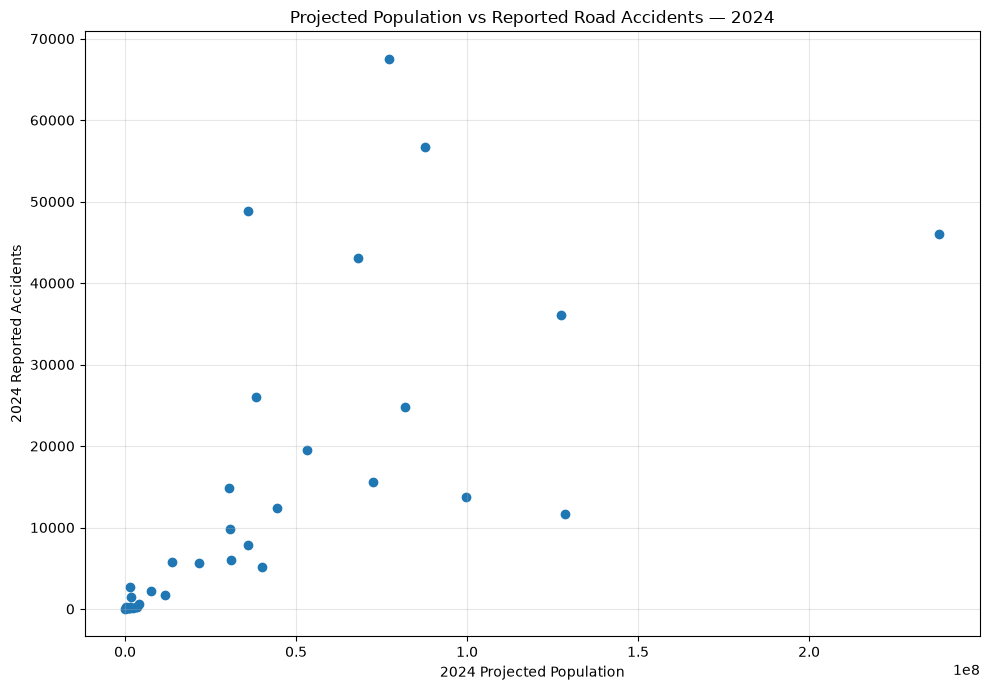

In [8]:
plt.figure(figsize=(10, 7))

plt.scatter(
    analysis_df["population_2024"],
    analysis_df["2024_accidents"]
)

plt.title(
    "Projected Population vs Reported Road Accidents — 2024"
)

plt.xlabel("2024 Projected Population")
plt.ylabel("2024 Reported Accidents")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Accidents V/S Fatalities

In [9]:
pearson_accidents_fatalities = stats.pearsonr(
    analysis_df["2024_accidents"],
    analysis_df["2024_killed"]
)

print(
    "Pearson correlation between accidents and fatalities: "
    f"{pearson_accidents_fatalities.statistic:.4f}"
)

print(
    "p-value: "
    f"{pearson_accidents_fatalities.pvalue:.6f}"
)

Pearson correlation between accidents and fatalities: 0.8632
p-value: 0.000000


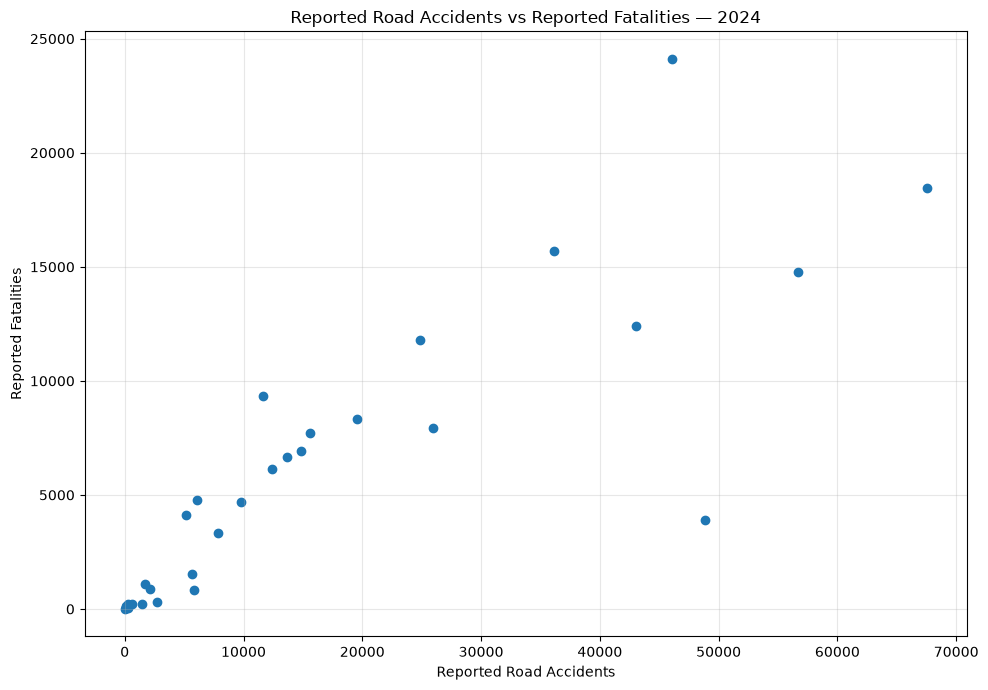

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    analysis_df["2024_accidents"],
    analysis_df["2024_killed"]
)

plt.title(
    "Reported Road Accidents vs Reported Fatalities — 2024"
)

plt.xlabel("Reported Road Accidents")
plt.ylabel("Reported Fatalities")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Population V/S Fatalities

In [11]:
pearson_population_fatalities = stats.pearsonr(
    analysis_df["population_2024"],
    analysis_df["2024_killed"]
)

print(
    "Pearson correlation between population and fatalities: "
    f"{pearson_population_fatalities.statistic:.4f}"
)

print(
    "p-value: "
    f"{pearson_population_fatalities.pvalue:.6f}"
)

Pearson correlation between population and fatalities: 0.9076
p-value: 0.000000


In [12]:
correlation_results = pd.DataFrame({
    "relationship": [
        "Population vs Accidents",
        "Population vs Fatalities",
        "Accidents vs Fatalities"
    ],
    "pearson_r": [
        pearson_population_accidents.statistic,
        pearson_population_fatalities.statistic,
        pearson_accidents_fatalities.statistic
    ],
    "p_value": [
        pearson_population_accidents.pvalue,
        pearson_population_fatalities.pvalue,
        pearson_accidents_fatalities.pvalue
    ]
})

display(correlation_results)

,relationship,pearson_r,p_value
0,Population vs Accidents,0.671499,7.348784e-06
1,Population vs Fatalities,0.907618,2.269190e-14
2,Accidents vs Fatalities,0.863164,1.266375e-11


In [13]:
spearman_population_accidents = stats.spearmanr(
    analysis_df["population_2024"],
    analysis_df["2024_accidents"]
)

spearman_population_fatalities = stats.spearmanr(
    analysis_df["population_2024"],
    analysis_df["2024_killed"]
)

spearman_accidents_fatalities = stats.spearmanr(
    analysis_df["2024_accidents"],
    analysis_df["2024_killed"]
)

spearman_results = pd.DataFrame({
    "relationship": [
        "Population vs Accidents",
        "Population vs Fatalities",
        "Accidents vs Fatalities"
    ],
    "spearman_rho": [
        spearman_population_accidents.statistic,
        spearman_population_fatalities.statistic,
        spearman_accidents_fatalities.statistic
    ],
    "p_value": [
        spearman_population_accidents.pvalue,
        spearman_population_fatalities.pvalue,
        spearman_accidents_fatalities.pvalue
    ]
})

display(spearman_results)

,relationship,spearman_rho,p_value
0,Population vs Accidents,0.894981,1.815936e-13
1,Population vs Fatalities,0.948777,1.384611e-18
2,Accidents vs Fatalities,0.942085,1.060270e-17


In [14]:
correlation_comparison = pd.DataFrame({
    "relationship": [
        "Population vs Accidents",
        "Population vs Fatalities",
        "Accidents vs Fatalities"
    ],
    "pearson_r": [
        pearson_population_accidents.statistic,
        pearson_population_fatalities.statistic,
        pearson_accidents_fatalities.statistic
    ],
    "spearman_rho": [
        spearman_population_accidents.statistic,
        spearman_population_fatalities.statistic,
        spearman_accidents_fatalities.statistic
    ]
})

display(correlation_comparison)

,relationship,pearson_r,spearman_rho
0,Population vs Accidents,0.671499,0.894981
1,Population vs Fatalities,0.907618,0.948777
2,Accidents vs Fatalities,0.863164,0.942085


In [15]:
# Create a helper function to remove the linear relationship
# between a variable and population.

def residualize(
    y: pd.Series,
    x: pd.Series
) -> pd.Series:

    slope, intercept = np.polyfit(x, y, 1)

    predicted = (
        slope * x
        + intercept
    )

    residuals = y - predicted

    return residuals


# Residual accidents after accounting for population
analysis_df["accident_residual"] = residualize(
    analysis_df["2024_accidents"],
    analysis_df["population_2024"]
)


# Residual fatalities after accounting for population
analysis_df["fatality_residual"] = residualize(
    analysis_df["2024_killed"],
    analysis_df["population_2024"]
)


display(
    analysis_df[
        [
            "state",
            "accident_residual",
            "fatality_residual"
        ]
    ].head()
)

,state,accident_residual,fatality_residual
0,Andhra Pradesh,2482.945613,1831.605141
1,Arunachal Pradesh,-4198.536443,-656.055762
2,Assam,-5017.218694,-1262.401234
3,Bihar,-23779.170536,-5439.734665
4,Chhattisgarh,3335.989918,2938.733896


In [16]:
partial_correlation = stats.pearsonr(
    analysis_df["accident_residual"],
    analysis_df["fatality_residual"]
)

print(
    "Correlation between accident and fatality residuals "
    "after accounting for population: "
    f"{partial_correlation.statistic:.4f}"
)

print(
    "p-value: "
    f"{partial_correlation.pvalue:.6f}"
)

Correlation between accident and fatality residuals after accounting for population: 0.8156
p-value: 0.000000


In [17]:
def interpret_p_value(p_value: float) -> str:

    if p_value < 0.01:
        return "Strong evidence against the null hypothesis (p < 0.01)."

    elif p_value < 0.05:
        return "Evidence against the null hypothesis (p < 0.05)."

    else:
        return "Insufficient evidence to reject the null hypothesis at the 5% level."


print(
    "Population vs accidents:"
)

print(
    interpret_p_value(
        pearson_population_accidents.pvalue
    )
)

print(
    "\nPopulation vs fatalities:"
)

print(
    interpret_p_value(
        pearson_population_fatalities.pvalue
    )
)

print(
    "\nAccidents vs fatalities:"
)

print(
    interpret_p_value(
        pearson_accidents_fatalities.pvalue
    )
)

print(
    "\nAccident vs fatality residuals:"
)

print(
    interpret_p_value(
        partial_correlation.pvalue
    )
)

Population vs accidents:
Strong evidence against the null hypothesis (p < 0.01).

Population vs fatalities:
Strong evidence against the null hypothesis (p < 0.01).

Accidents vs fatalities:
Strong evidence against the null hypothesis (p < 0.01).

Accident vs fatality residuals:
Strong evidence against the null hypothesis (p < 0.01).


In [18]:
statistical_summary = pd.DataFrame({
    "analysis": [
        "Population vs Accidents",
        "Population vs Fatalities",
        "Accidents vs Fatalities",
        "Accidents vs Fatalities after accounting for Population"
    ],
    "correlation": [
        pearson_population_accidents.statistic,
        pearson_population_fatalities.statistic,
        pearson_accidents_fatalities.statistic,
        partial_correlation.statistic
    ],
    "p_value": [
        pearson_population_accidents.pvalue,
        pearson_population_fatalities.pvalue,
        pearson_accidents_fatalities.pvalue,
        partial_correlation.pvalue
    ]
})

display(statistical_summary)

,analysis,correlation,p_value
0,Population vs Accidents,0.671499,7.348784e-06
1,Population vs Fatalities,0.907618,2.269190e-14
2,Accidents vs Fatalities,0.863164,1.266375e-11
3,Accidents vs Fatalities after accounting for P...,0.815565,1.374715e-09


In [19]:
output_path = (
    "../data/processed/"
    "statistical_analysis_results_2024.csv"
)

statistical_summary.to_csv(
    output_path,
    index=False
)

print("Statistical results saved:")
print(output_path)

Statistical results saved:
../data/processed/statistical_analysis_results_2024.csv


In [20]:
residual_output_path = (
    "../data/processed/"
    "population_adjusted_accident_fatality_residuals_2024.csv"
)

analysis_df[
    [
        "state",
        "2024_accidents",
        "2024_killed",
        "population_2024",
        "accident_residual",
        "fatality_residual"
    ]
].to_csv(
    residual_output_path,
    index=False
)

print("Residual dataset saved:")
print(residual_output_path)

Residual dataset saved:
../data/processed/population_adjusted_accident_fatality_residuals_2024.csv


## Statistical Analysis — Initial Findings

The statistical analysis confirms the relationships observed during
exploratory analysis using formal correlation measures.

Pearson correlation is used to quantify linear association, while Spearman
correlation provides a rank-based measure that is less dependent on a
strictly linear relationship.

The analysis also examines the accident–fatality relationship after
accounting for the linear association of each variable with projected
population.

These results should be interpreted as observational associations at the
State/UT level. They do not establish causation.

A strong accident–fatality correlation may partly reflect differences in
population size, traffic exposure and other factors that are not explicitly
represented in the current dataset.

The statistical findings should therefore be treated as evidence for further
investigation rather than as proof that one variable causes another.

## Statistical Analysis — Final Findings

All three primary Pearson correlations are statistically significant at the
5% significance level.

Projected population and reported accidents show a positive association
(Pearson r = 0.6715, p < 0.001).

Projected population and reported fatalities show a very strong positive
association (Pearson r = 0.9076, p < 0.001).

Reported accidents and reported fatalities show a strong positive association
(Pearson r = 0.8632, p < 0.001).

After accounting for the linear relationship of both variables with projected
population, the association between reported accidents and reported
fatalities remains strong and statistically significant (r = 0.8156,
p < 0.001).

These findings indicate that the accident–fatality association is not
explained solely by differences in population size within this State/UT-level
dataset.

However, the analysis is observational, uses only 36 State/UT observations,
and does not account for all relevant factors such as traffic exposure,
vehicle usage, road characteristics, speed, emergency response and reporting
practices. Therefore, the results indicate statistical association rather
than causation.